In [17]:
import alphapepttools as apt
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import mudata as md
import pandas as pd

# Mirror the central alphapepttools plot settings (defaults.PlotSettings) onto matplotlib's
# global rcParams so notebook figures match the library defaults.
from alphapepttools.pl import defaults
from matplotlib.patches import Patch

In [18]:

_plot_config = defaults.plot_settings.to_dict()
plt.rcParams.update(
    {
        "font.size": _plot_config["font_sizes"]["medium"],
        "axes.titlesize": _plot_config["axes"]["title_size"],
        "axes.labelsize": _plot_config["axes"]["label_size"],
        "xtick.labelsize": _plot_config["axes"]["tick_size"],
        "ytick.labelsize": _plot_config["axes"]["tick_size"],
        "legend.fontsize": _plot_config["legend"]["font_size"],
        "legend.title_fontsize": _plot_config["legend"]["title_size"],
        "lines.linewidth": _plot_config["linewidths"]["medium"],
        "lines.markersize": _plot_config["marker_sizes"]["medium"],
        "figure.dpi": _plot_config["resolution"]["dpi"],
        "savefig.dpi": _plot_config["resolution"]["dpi"],
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,
    }
)

# Shared color scheme for the omics modalities, reused across loading and enrichment plots
palette = {"proteins": "#9ED8CB", "rna": "#BDCEE5", "methylation": "#D5BDDE"}

figure_output_dir = "../../../../assets/study_05_multimodal"

## Functions

In [19]:
def plot_modality_loadings(
    data: pd.DataFrame,
    *,
    score: str,
    feature: str,
    palette: dict,
    modality_column: str = "modality",
    xlabel: str = "Score",
    ax: plt.Axes | None = None,
    fontsize: int = 5,
    legend: bool = True,
) -> plt.Axes:
    """Horizontal bar plot of per-feature scores, colored by omics modality.

    Used to display either MOFA+ factor loadings or gene set enrichment scores. Each
    bar corresponds to a single feature (a gene or a pathway) and is colored by the
    modality it originates from.

    Parameters
    ----------
    data
        Long-format dataframe with one row per feature.
    score
        Column holding the numeric value drawn as bar length (x-axis).
    feature
        Column holding the feature labels shown on the y-axis.
    palette
        Mapping of modality name to color.
    modality_column
        Column holding the modality of each feature.
    xlabel
        Label of the x-axis.
    ax
        Axes to draw on. If `None`, a new figure and axes are created.

    Notes
    -----
    Feature labels that occur more than once in `data` (e.g. a pathway or gene shared
    across modalities) are rendered in bold to highlight cross-modal agreement.
    """
    data = data.sort_values(by=score)
    colors = data[modality_column].map(palette)

    if ax is None:
        _, ax = plt.subplots(figsize=(4, 8))

    ax.barh(range(len(data)), data[score], color=colors)
    ax.set_yticks(range(len(data)))
    ax.set_ylim(-0.5, len(data) - 0.5)
    labels = ax.set_yticklabels(data[feature], fontsize=fontsize)

    # Highlight features that occur in more than one row (e.g. shared across modalities)
    feature_counts = data[feature].value_counts()
    for label, name in zip(labels, data[feature], strict=True):
        if feature_counts[name] > 1:
            label.set_fontweight("bold")
    ax.axvline(0, color="black", linewidth=0.8)  # zero reference line
    ax.set_xlabel(xlabel, labelpad=0)

    # Legend mapping each color back to its modality
    if legend:
        handles = [
            mpatches.Patch(color=color, label=modality)
            for modality, color in palette.items()
        ]
        ax.legend(
            handles=handles,
            title="Modality",
            bbox_to_anchor=(1.01, 1),
            loc="upper left",
        )

    ax.spines[["top", "right"]].set_visible(False)
    return ax

## Factor loadings

### Load Data

In [20]:
mdata = md.read_h5mu("../data/pp/lehtio2021_nsclc_multimodal.h5mu")

mofa_loadings = pd.DataFrame(
    mdata.varm["LFs"],
    index=pd.MultiIndex.from_frame(
        mdata.var.reset_index(names="genes")[["genes", "modality"]]
    ),
)

/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/io.py:495: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  return func(elem)
/Users/vincenthbrennsteiner/miniconda3/envs/apt_study_05_multimodal/lib/python3.13/site-packages/mudata/_core/mudata.py:988: UserWarning: var_names are not unique. To make them unique, call `.var_names_make_unique`.
  self._update_attr("var", axis=1, join_common=join_common)


#### [Miniaturized figure for manuscript]

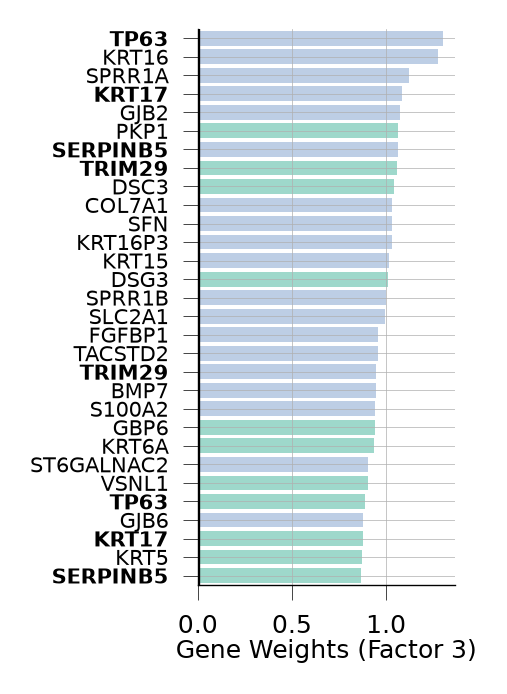

In [21]:
FACTOR = 2  # zero-indexed

fig, axm = apt.pl.create_figure(1, 1, figsize=(1.5, 2.2))
plot_modality_loadings(
    mofa_loadings.reset_index().nlargest(30, FACTOR),
    score=FACTOR,
    feature="genes",
    modality_column="modality",
    palette=palette,
    ax=axm[0],
    xlabel=f"Gene Weights (Factor {FACTOR + 1})",
    legend=False,
)
plt.xticks([0, 0.5, 1.0])

apt.pl.save_figure(
    fig = fig,
    filename = f"mofa_loadings_factor-{FACTOR}.png",
    output_dir = figure_output_dir,
    dpi = 600,
    transparent = True,
)


## Legend

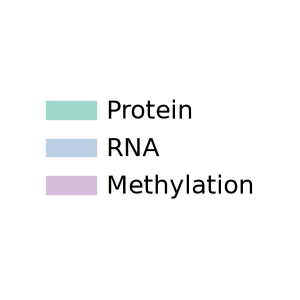

In [ ]:
handles = [Patch(color=color) for color in palette.values()]
labels = ["Protein", "RNA", "Methylation"]

fig, axm = apt.pl.create_figure(1, 1, figsize=("0.25", "0.25"))
ax = axm.next()

ax.legend(
    handles,
    labels,
    loc="center",
    title=None,
    title_fontproperties={"weight": "bold"},
    alignment="left",
    facecolor="#ffffff",
    framealpha=0.3,
    ncols=1,
    columnspacing=0.0,
    frameon=False,
    handletextpad=0.4,
)
ax.set_axis_off()

# plt.tight_layout()

apt.pl.save_figure(
    fig = fig,
    filename = f"mofa_loadings_factor-{FACTOR}.legend.png",
    output_dir = figure_output_dir,
    dpi = 600,
    transparent = True,
)

plt.show()